## Question 1 SOLUTION: Predict Food Delivery Time

You are provided with a food delivery dataset that includes features such as delivery distance, restaurant preparation time, traffic conditions, and order details. Your objective is to develop a regression model that accurately predicts the delivery time in minutes.

Your target is the column: "delivery_time".

You are provided with the code to download and load the csv file.

Your work will be evaluated based on the completion of the following tasks:


# Part 1: Read Data

**Tasks:**

1. Read the dataset using `read_csv()`
2. Inspect the first few rows using `head()`
3. Display dataset information using `info()`
4. Show statistical description using `describe()`
5. Plot the target distribution (delivery_time)

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mohammad2012191/q1-ka-ai-2026")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\moham\.cache\kagglehub\datasets\mohammad2012191\q1-ka-ai-2026\versions\1


In [4]:
import pandas as pd
import os
df = pd.read_csv(os.path.join(path, 'Q1_data.csv'))
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [3]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43.0
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84.0
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59.0
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37.0
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1663 entries, 0 to 1662
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1663 non-null   int64  
 1   Distance_km             1663 non-null   float64
 2   Weather                 1608 non-null   object 
 3   Traffic_Level           1612 non-null   object 
 4   Time_of_Day             1613 non-null   object 
 5   Vehicle_Type            1663 non-null   object 
 6   Preparation_Time_min    1663 non-null   int64  
 7   Courier_Experience_yrs  1614 non-null   float64
 8   Delivery_Time           1557 non-null   float64
dtypes: float64(3), int64(2), object(4)
memory usage: 117.1+ KB


In [5]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time
count,1663.000000,1663.000000,1663.000000,1614.000000,1557.000000
mean,495.866506,10.049910,17.038485,4.586741,56.640976
std,289.514088,5.684406,7.230498,2.916843,22.135919
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,246.500000,5.130000,11.000000,2.000000,41.000000
50%,490.000000,10.160000,17.000000,5.000000,55.000000
75%,745.500000,14.980000,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


<Axes: >

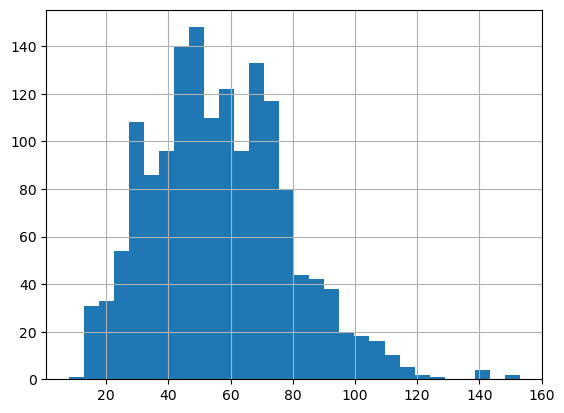

In [6]:
df['Delivery_Time'].hist(bins=30)

# Part 2: Data Cleaning

**Tasks:**

Inspect and fix the following when needed:

1. **Drop the 'Order_ID' column from the data** 
2. **Handle missing values appropriately** (Hint: I guess you want to have a closer look at the columns with missing values :) )
3. **Check and remove duplicates** if any exist
4. **Encode categorical variables** if needed
5. **Apply feature scaling** to numerical features (Use StandardScaler)
6. **Check for target imbalance and state if it is imbalanced or not** (keep this cell empty if not needed)

In [ ]:
# Task 1
df = df.drop('Order_ID', axis=1)

In [ ]:
# Task 2
# Drop rows with missing target
df = df.dropna(subset=['Delivery_Time'])
# Fill missing values
df = df.fillna(df.median(numeric_only=True))
df = df.fillna(df.mode().iloc[0])

In [ ]:
# Task 3
df = df.drop_duplicates()

In [11]:
# Task 4
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes("object").columns
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [ ]:
# Task 5
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_cols = [col for col in df.columns if col != 'Delivery_Time']
df[X_cols] = scaler.fit_transform(df[X_cols])

In [ ]:
# Task 6
# Not applicable for regression

# Part 3: Modeling

**Tasks:**

1. Split the dataset into features (X) and target (y)
2. Use the correct split: **KFold** OR **StratifiedKFold**
3. Train a **RandomForest** model
4. Evaluate using **MAE (Mean Absolute Error) ONLY**
5. Print the averaged score across all folds

In [13]:
X = df.drop('Delivery_Time', axis=1)
y = df['Delivery_Time']

In [14]:
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = RandomForestRegressor(random_state=42)
scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    scores.append(mean_absolute_error(y_val, y_pred))

print(f'Average MAE: {np.mean(scores):.2f}')

Average MAE: 7.80


# Part 4: Plots

**Tasks:**

1. Plot feature importance from your trained model
2. Plot predicted delivery time histogram

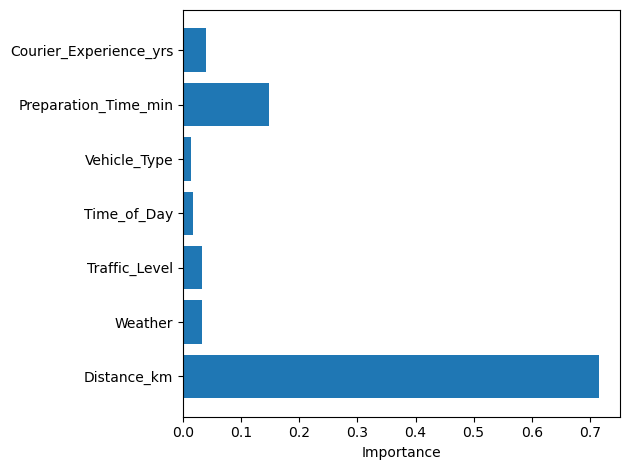

In [15]:
import matplotlib.pyplot as plt
plt.barh(X.columns, model.feature_importances_)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

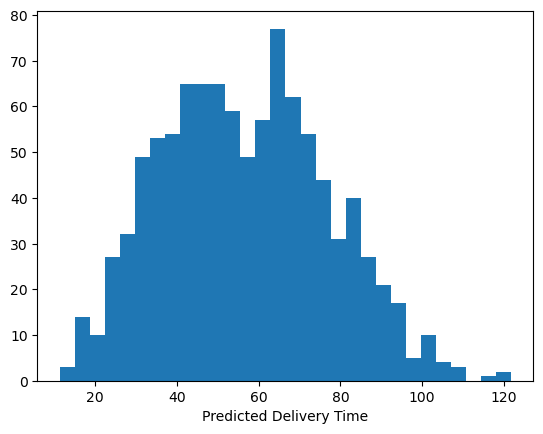

In [16]:
y_pred = model.predict(X)
plt.hist(y_pred, bins=30)
plt.xlabel('Predicted Delivery Time')
plt.show()

# Part 5: Bonus - Ensemble

**Task:**

Why use one model? Let's use 2 then merge!

Rewrite the KFold loop such that you:
1. Train **2 different models** inside the loop at the same time in each iteration
2. Average their predictions
3. Calculate the MAE metric on the averaged predictions

Use RandomForestRegressor and CatBoostRegressor.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model1 = RandomForestRegressor(random_state=42)
model2 = CatBoostRegressor(verbose=0, random_state=42)
scores = []

for train_idx, val_idx in kf.split(X):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model1.fit(X_train, y_train)
    model2.fit(X_train, y_train)
    
    y_pred1 = model1.predict(X_val)
    y_pred2 = model2.predict(X_val)
    y_pred_avg = (y_pred1 + y_pred2) / 2
    
    scores.append(mean_absolute_error(y_val, y_pred_avg))

print(f'Average MAE (Ensemble): {np.mean(scores):.2f}')

Average MAE (Ensemble): 7.43
